In [1]:
!pip install pandas scikit-learn

import pandas as pd

In [2]:
df = pd.read_csv("travel_health_dataset.csv")
df.head()

,country_risk,duration_days,age_group,vaccinated,pre_existing_condition,risk_level
0,High,3,Adult,No,No,Medium
1,Low,16,Young,Yes,No,Low
2,High,9,Young,Yes,Yes,Medium
3,High,4,Young,Yes,Yes,Medium
4,Low,1,Senior,Yes,Yes,Low


In [3]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop("risk_level", axis=1)
y = df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [6]:
import os
import pickle

os.makedirs("models", exist_ok=True)

pickle.dump(model, open("models/model.pkl", "wb"))
pickle.dump(encoders, open("models/encoders.pkl", "wb"))

In [7]:
def predict_risk(input_dict):
    encoded = []
    
    for col, value in input_dict.items():
        le = encoders[col]
        encoded.append(le.transform([value])[0])
    
    return model.predict([encoded])[0]

In [8]:
def get_recommendation(risk):
    if risk == 2:
        return "High Risk: Quarantine, consult doctor"
    elif risk == 1:
        return "Medium Risk: Monitor symptoms"
    else:
        return "Low Risk: Stay safe"

In [9]:
sample = {
    "country_risk": "High",
    "duration_days": 12,
    "age_group": "Senior",
    "vaccinated": "No",
    "pre_existing_condition": "Yes"
}

risk = predict_risk(sample)

print("Encoded Risk:", risk)
print(get_recommendation(risk))

Encoded Risk: 0
Low Risk: Stay safe


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


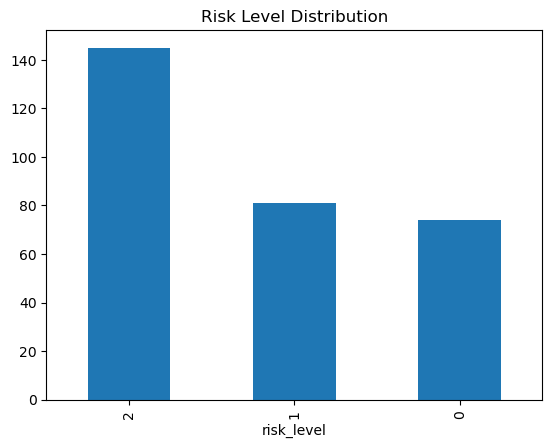

In [10]:
import matplotlib.pyplot as plt

df['risk_level'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.show()